## Imports

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import scale

from lib.sb_utils import save_file

## Load Cleaned Data

In [22]:
# Load cleaned data and visualize
college_data = pd.read_csv('../data/college_data_cleaned.csv')
college_data.head()

,name,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Room.Board,Books,PhD,S.F.Ratio,perc.alumni,Expend,Grad.Rate,state,degree_length,out_of_state_tuition
0,Alaska Pacific University,1,193,146,55,16,44,249,869,4120,800,76,11.9,2,10922,15,Alaska,4,20830.0
1,Albright College,1,1038,839,227,30,63,973,306,4400,300,79,11.3,23,11644,80,Pennsylvania,4,45306.0
2,Amherst College,1,4302,992,418,83,96,1593,5,5300,660,93,8.4,63,21424,100,Massachusetts,4,56426.0
3,Auburn University-Main Campus,0,7548,6791,3070,25,57,16262,1716,3933,600,85,16.7,18,6642,69,Alabama,4,30524.0
4,Augustana College,1,761,725,306,21,58,1337,300,3244,600,66,10.4,30,6871,69,Illinois,4,42135.0


In [23]:
college_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349 entries, 0 to 348
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  349 non-null    object 
 1   Private               349 non-null    int64  
 2   Apps                  349 non-null    int64  
 3   Accept                349 non-null    int64  
 4   Enroll                349 non-null    int64  
 5   Top10perc             349 non-null    int64  
 6   Top25perc             349 non-null    int64  
 7   F.Undergrad           349 non-null    int64  
 8   P.Undergrad           349 non-null    int64  
 9   Room.Board            349 non-null    int64  
 10  Books                 349 non-null    int64  
 11  PhD                   349 non-null    int64  
 12  S.F.Ratio             349 non-null    float64
 13  perc.alumni           349 non-null    int64  
 14  Expend                349 non-null    int64  
 15  Grad.Rate             3

## Tuition Visualizations

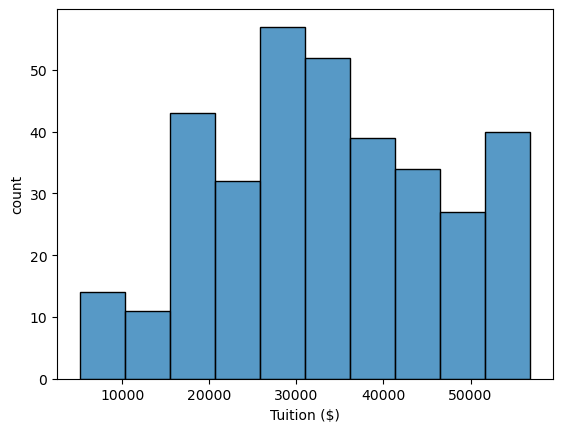

In [24]:
# Tuition Distribution
sns.histplot(data=college_data, x='out_of_state_tuition')
plt.xlabel('Tuition ($)')
plt.ylabel('count');

In [25]:
# View colleges with most and least tuition
college_data[['name','out_of_state_tuition']].sort_values(by='out_of_state_tuition', ascending=True).reset_index(drop=True)

,name,out_of_state_tuition
0,Franklin Pierce College,5112.0
1,North Park College,5220.0
2,Lesley College,5313.0
3,Southwestern Adventist College,6550.0
4,Huntington College,6635.0
...,...,...
344,Colorado College,55470.0
345,Colgate University,55870.0
346,Sarah Lawrence College,55900.0
347,Amherst College,56426.0


In [26]:
# Tuition averages per state (for visualization only).
state_means = college_data.groupby("state")["out_of_state_tuition"].mean().round(2)
state_means.head()

state
Alabama       22816.29
Alaska        20830.00
Arkansas      26790.00
California    46781.28
Colorado      32213.33
Name: out_of_state_tuition, dtype: float64

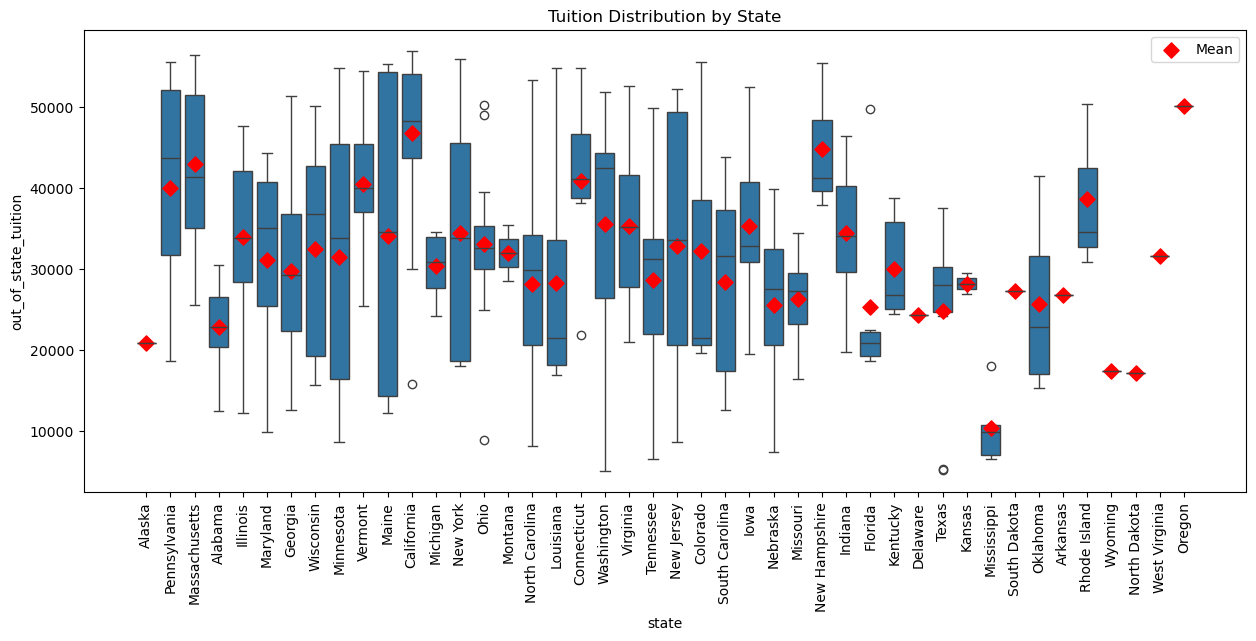

In [27]:
# Plot tuition box plot by state
plt.figure(figsize=(15,6))
sns.boxplot(x="state", y="out_of_state_tuition", data=college_data)
plt.scatter(x=state_means.index, y=state_means.values,
            color="red", marker="D", zorder=2, s=60, label="Mean")
plt.xticks(rotation=90)
plt.legend()
plt.title("Tuition Distribution by State")
plt.show()

In [28]:
# Retain `state` — it's used in Modeling.ipynb to compute state_mean from training data only.
college_data.columns

Index(['name', 'Private', 'Apps', 'Accept', 'Enroll', 'Top10perc', 'Top25perc',
       'F.Undergrad', 'P.Undergrad', 'Room.Board', 'Books', 'PhD', 'S.F.Ratio',
       'perc.alumni', 'Expend', 'Grad.Rate', 'state', 'degree_length',
       'out_of_state_tuition'],
      dtype='object')

## Feature Analysis

When looking at the feature of interest, out_of_state_tuition, it can be seen that the features 
'Apps', 'Accept', 'Enroll', 'F.Undergrad', 'P.Undergrad', 'Books', and 'degree_length' are not significant features.
We can remove those rows below.

These are all fairly surprising that there isn't as much correlation.

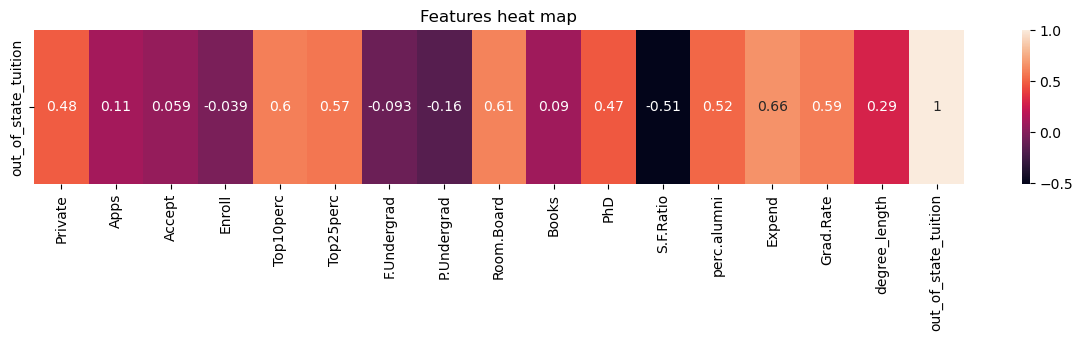

In [29]:
# Features heat map
plt.subplots(figsize=(15,2))
sns.heatmap(college_data.select_dtypes(include='number').corr()[['out_of_state_tuition']].T, annot=True)
plt.title('Features heat map');

In [30]:
# Drop low correlation features
college_data.drop(['Apps', 'Accept', 'Enroll', 'F.Undergrad', 'P.Undergrad', 'Books', 'degree_length'], axis=1, inplace=True)
college_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349 entries, 0 to 348
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  349 non-null    object 
 1   Private               349 non-null    int64  
 2   Top10perc             349 non-null    int64  
 3   Top25perc             349 non-null    int64  
 4   Room.Board            349 non-null    int64  
 5   PhD                   349 non-null    int64  
 6   S.F.Ratio             349 non-null    float64
 7   perc.alumni           349 non-null    int64  
 8   Expend                349 non-null    int64  
 9   Grad.Rate             349 non-null    int64  
 10  state                 349 non-null    object 
 11  out_of_state_tuition  349 non-null    float64
dtypes: float64(2), int64(8), object(2)
memory usage: 32.8+ KB


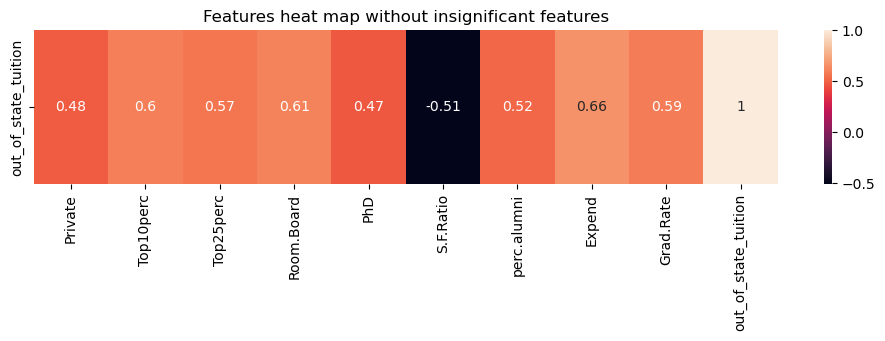

In [31]:
# New heatmap without 'redudant' features
plt.subplots(figsize=(12,2))
sns.heatmap(college_data.select_dtypes(include='number').corr()[['out_of_state_tuition']].T, annot=True)
plt.title('Features heat map without insignificant features');

In [32]:
# This function creates scatterplots of the features against the target feature, 'out_of_state_tuition'
def scatterplots(columns, ncol, figsize=(15, 8)):
    nrow = int(np.ceil(len(columns) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(5*ncol, 4*nrow))
    fig.subplots_adjust(wspace=0.5, hspace=0.6)
    for i, col in enumerate(columns):
        ax = axes.flatten()[i]
        ax.scatter(x = col, y = 'out_of_state_tuition', data=college_data, alpha=0.5)
        ax.set(xlabel=col, ylabel='Tuition')
    nsubplots = nrow * ncol
    for empty in range(i+1, nsubplots):
        axes.flatten()[empty].set_visible(False)

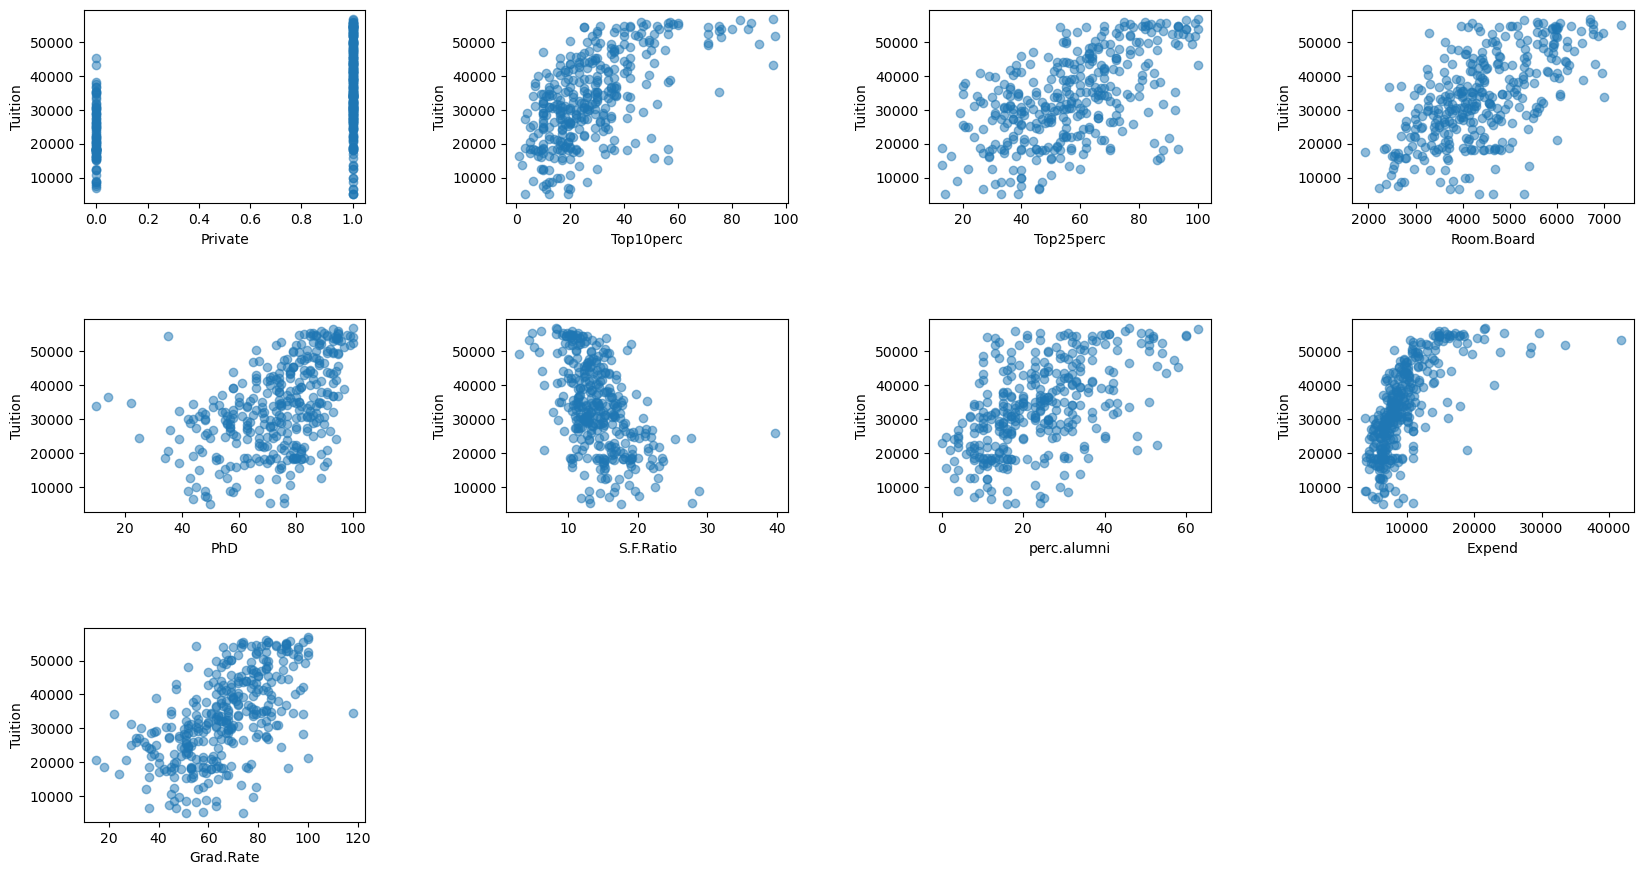

In [33]:
features = college_data.drop(['out_of_state_tuition', 'name', 'state'], axis=1)
scatterplots(features, ncol=4, figsize=(15, 15))

There is clear correlation in all features except the Private feature which is due to the nature of a boolean feature.<br><br>
The following is a full description of the features:<br>
<br>
Tuition: Out of state tuition<br>
Private: private of public university (1 signifies private)<br>
Top10perc: Percent new students from top 10% of H.S. class<br>
Top25perc: Percent new students from top 25% of H.S. class<br>
Room.Board: Room and board costs<br>
PhD: Percent of faculty with Ph.D.’s<br>
S.F.Ratio: Student/faculty ratio<br>
perc.alumni: Percent alumni who donate<br>
Expend: Instructional expenditure per student<br>
Grad.Rate: Graduation rate<br>
state_mean: mean tuition of the respective state<br>
<br>

## Data Sanity Check

All features correlation seem to make visual and logical sense besides 'Grad.Rate' which has a few concerning values. There is one entry above a 100% graduation which is obviously not valid. The entries at 100% should also be investigated.

In [34]:
# First look at entry above 100% graduation rate
print(college_data.loc[college_data['Grad.Rate'] > 100, ['name', 'Grad.Rate']])

                 name  Grad.Rate
28  Cazenovia College        118


Cazenovia College has their graduation rate set at 118. With a simple google search the graduation rate in 2018 for Cazenovia College is actually 65%.

In [35]:
# Fix Grad.Rate
college_data.loc[college_data.name == 'Cazenovia College', 'Grad.Rate'] = 65
print(college_data[college_data['name'] == 'Cazenovia College'])

                 name  Private  Top10perc  Top25perc  Room.Board  PhD  \
28  Cazenovia College        1          9         35        4840   22   

    S.F.Ratio  perc.alumni  Expend  Grad.Rate     state  out_of_state_tuition  
28       14.3           20    7697         65  New York               34630.0  


In [36]:
# Investigating entries at 100% graduation rate
print(college_data[college_data['Grad.Rate'] == 100].name)

2                  Amherst College
40     College of Mount St. Joseph
96             Harvey Mudd College
216         Santa Clara University
294         University of Richmond
Name: name, dtype: object


Using a google search, these values are found to be consistent with a very high graduation rate.

In [37]:
# Statistical description of features
college_data.describe()

,Private,Top10perc,Top25perc,Room.Board,PhD,S.F.Ratio,perc.alumni,Expend,Grad.Rate,out_of_state_tuition
count,349.000000,349.000000,349.000000,349.000000,349.000000,349.000000,349.000000,349.000000,349.000000,349.000000
mean,0.739255,27.925501,56.478510,4386.613181,73.343840,14.223782,23.601719,9635.544413,66.060172,33328.369628
std,0.439671,17.746301,19.805889,1085.997040,16.078001,4.084500,12.773855,4660.811551,17.166338,12804.964008
min,0.000000,1.000000,13.000000,1920.000000,10.000000,2.900000,0.000000,3733.000000,15.000000,5112.000000
25%,0.000000,16.000000,40.000000,3620.000000,63.000000,11.500000,14.000000,6719.000000,54.000000,24262.000000
50%,1.000000,25.000000,55.000000,4240.000000,76.000000,13.700000,23.000000,8355.000000,66.000000,32730.000000
75%,1.000000,36.000000,70.000000,5140.000000,85.000000,16.300000,32.000000,10872.000000,79.000000,43450.000000
max,1.000000,96.000000,100.000000,7350.000000,100.000000,39.800000,63.000000,41766.000000,100.000000,56876.000000


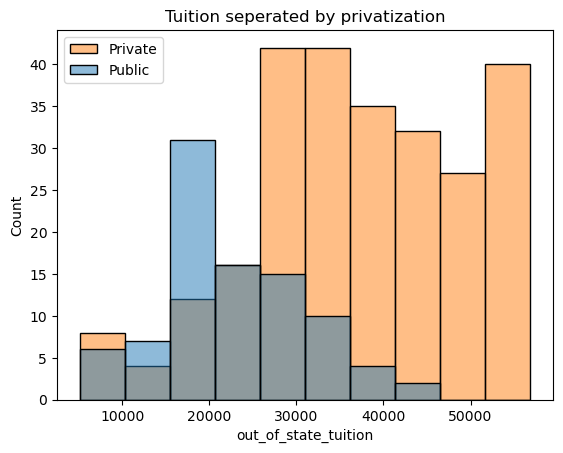

In [38]:
# Distribution visualization of tuition seperated by privatization
sns.histplot(data=college_data, x='out_of_state_tuition', hue='Private')
plt.legend(['Private', 'Public'])
plt.title("Tuition seperated by privatization");

This is a better visualization of the binary 'Private' feature.

PCA is not necessary as there are very few features already.

## Summary and Save

In [39]:
college_data.head()

,name,Private,Top10perc,Top25perc,Room.Board,PhD,S.F.Ratio,perc.alumni,Expend,Grad.Rate,state,out_of_state_tuition
0,Alaska Pacific University,1,16,44,4120,76,11.9,2,10922,15,Alaska,20830.0
1,Albright College,1,30,63,4400,79,11.3,23,11644,80,Pennsylvania,45306.0
2,Amherst College,1,83,96,5300,93,8.4,63,21424,100,Massachusetts,56426.0
3,Auburn University-Main Campus,0,25,57,3933,85,16.7,18,6642,69,Alabama,30524.0
4,Augustana College,1,21,58,3244,66,10.4,30,6871,69,Illinois,42135.0


In [40]:
# Save the data
save_file(college_data, 'college_data_EDA.csv', '../data')

A file already exists with this name.

Writing file.  "../data/college_data_EDA.csv"
